# ELSA: Exact Linear-Scan Attention

корпус: IMDB Reviews(беру 8 000 train + 2 000 test)
задача: sentiment analysis — по тексту отзыва определить, положительный он или отрицательный.

In [7]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124

!pip install https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.5.0.post8/causal_conv1d-1.5.0.post8+cu12torch2.5cxx11abiFALSE-cp312-cp312-linux_x86_64.whl
!pip install https://github.com/state-spaces/mamba/releases/download/v2.2.4/mamba_ssm-2.2.4+cu12torch2.5cxx11abiFALSE-cp312-cp312-linux_x86_64.whl

!pip install packaging triton timm==0.4.12 pytest chardet yacs termcolor submitit tensorboardX fvcore seaborn opencv-python tensorboard
!pip install transformers==4.40.0
!pip install datasets==2.20.0 scikit-learn matplotlib pandas tqdm

Found existing installation: torch 2.5.1+cu124
Uninstalling torch-2.5.1+cu124:
  Successfully uninstalled torch-2.5.1+cu124
Found existing installation: torchvision 0.20.1+cu124
Uninstalling torchvision-0.20.1+cu124:
  Successfully uninstalled torchvision-0.20.1+cu124
Found existing installation: torchaudio 2.5.1+cu124
Uninstalling torchaudio-2.5.1+cu124:
  Successfully uninstalled torchaudio-2.5.1+cu124
Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.5.1%2Bcu124-cp312-cp312-linux_x86_64.whl (908.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.20.1%2Bcu124-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.5.1%2Bcu124-cp312-cp312-linux_x86_64.whl (3.4 MB)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 MB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.6 MB/s eta 0:00:00
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=204e6983125af0619230b063208a5db2ef143b88c3a16a99594a45b9219b1b4e
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=8e

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the f

In [15]:
import torch, sys, platform
print("CUDA   :", torch.cuda.is_available(), ", device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

try:
    from mamba_ssm import Mamba
    print("Mamba  : OK")
except Exception as e:
    print("Mamba FAIL:", e)

import transformers, datasets, sklearn

CUDA   : True , device: Tesla T4
Mamba  : OK


In [32]:
import os, random, numpy as np

class CFG:
    seed   = 42
    max_len= 256
    vocab_name  = "bert-base-uncased"
    batch_size  = 32
    d_model= 128
    n_heads= 4
    n_layers    = 2
    n_classes   = 2
    dropout= 0.1
    lr= 3e-4
    epochs = 25
    train_size  = 8000
    test_size   = 2000
    device= "cuda"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

In [18]:
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

raw = load_dataset("imdb")
tokenizer = AutoTokenizer.from_pretrained(CFG.vocab_name)
VOCAB_SIZE = tokenizer.vocab_size
PAD_ID = tokenizer.pad_token_id

train_raw = raw["train"].shuffle(seed=CFG.seed).select(range(CFG.train_size))
test_raw  = raw["test"].shuffle(seed=CFG.seed).select(range(CFG.test_size))

def encode(batch):
    enc = tokenizer(
        batch["text"],
        max_length=CFG.max_len,
        padding="max_length",
        truncation=True,
    )
    enc["labels"] = batch["label"]
    return enc

train_tok = train_raw.map(encode, batched=True, remove_columns=["text", "label"])
test_tok  = test_raw.map(encode,  batched=True, remove_columns=["text", "label"])

def collate(batch):
    return {
        "input_ids":      torch.tensor([b["input_ids"]      for b in batch], dtype=torch.long),
        "attention_mask": torch.tensor([b["attention_mask"] for b in batch], dtype=torch.long),
        "labels":         torch.tensor([b["labels"]         for b in batch], dtype=torch.long),
    }

train_loader = DataLoader(train_tok, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate)
test_loader  = DataLoader(test_tok,  batch_size=CFG.batch_size, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate)

print(f"Vocab size : {VOCAB_SIZE}")
print(f"Train batch: {len(train_loader)}, Test batch: {len(test_loader)}")
batch = next(iter(train_loader))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Vocab size : 30522
Train batch: 250, Test batch: 63


In [5]:
!pip install -q -U "datasets>=3.0.0" "pyarrow>=17.0.0" "fsspec>=2024.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 20.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import math
from mamba_ssm import Mamba
import time
from tqdm.auto import tqdm
import gc, pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos = nn.Embedding(max_len, d_model)
    def forward(self, x):
        B, T, _ = x.shape
        pos_ids = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        return x + self.pos(pos_ids)

class FFN(nn.Module):
    def __init__(self, d_model, mult=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, mult * d_model), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mult * d_model, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)

class AttentionBlock(nn.Module):
    def __init__(self, attention_module, d_model, dropout=0.1):
        super().__init__()
        self.attn = attention_module
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = FFN(d_model, mult=4, dropout=dropout)
    def forward(self, x, mask=None):
        x = x + self.attn(self.norm1(x), mask)
        x = x + self.ffn(self.norm2(x))
        return x

class SequenceClassifier(nn.Module):
    def __init__(self, attention_factory, vocab_size, cfg: CFG):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, cfg.d_model, padding_idx=PAD_ID)
        self.pos = PositionalEmbedding(cfg.max_len, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([
            AttentionBlock(attention_factory(), cfg.d_model, cfg.dropout)
            for _ in range(cfg.n_layers)
        ])
        self.norm = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.n_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.drop(self.pos(self.tok(input_ids)))
        for blk in self.blocks:
            x = blk(x, attention_mask)
        x = self.norm(x)
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            x = (x * m).sum(1) / m.sum(1).clamp(min=1.0)
        else:
            x = x.mean(1)
        return self.head(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [20]:
class MHA(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dk = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, D = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.h, self.dk).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                       # [B, h, T, dk]
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dk)
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, D)
        return self.proj(out)

In [21]:
class LinearAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1, eps=1e-6):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dk = d_model // n_heads
        self.eps = eps
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    @staticmethod
    def phi(x):
        return F.elu(x) + 1.0

    def forward(self, x, mask=None):
        B, T, D = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.h, self.dk).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = self.phi(q); k = self.phi(k)

        if mask is not None:
            m = mask[:, None, :, None].float()
            k = k * m
            v = v * m

        kv = torch.einsum("bhtd,bhte->bhde", k, v)
        k_sum = k.sum(dim=2)
        z = torch.einsum("bhtd,bhd->bht", q, k_sum) + self.eps
        num = torch.einsum("bhtd,bhde->bhte", q, kv)
        out = num / z.unsqueeze(-1)
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.drop(self.proj(out))

In [22]:
class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.mamba = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand,
        )

    def forward(self, x, mask=None):
        y = self.mamba(x)
        if mask is not None:
            y = y * mask.unsqueeze(-1).float()
        return y

У меня ELSA - последовательный цикл на Python, который обрабатывает токены по одному(->не очень быстро работает из-за отсутствия параллелизма).
В статье этот процесс преобразуется в дерево глубины log(T)-> параллельность вычисления на GPU через CUDA



In [23]:
class ELSAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dk = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    def _online_softmax_attention(self, q, k, v, mask=None):
        B, H, T, dk = q.shape
        dv = v.shape[-1]
        scale = 1.0 / math.sqrt(dk)

        m = torch.full((B, H, T, 1), float("-inf"), device=q.device, dtype=q.dtype)
        S = torch.zeros((B, H, T, 1),  device=q.device, dtype=q.dtype)
        W = torch.zeros((B, H, T, dv), device=q.device, dtype=q.dtype)

        for j in range(T):
            s_j = (q @ k[:, :, j:j+1, :].transpose(-2, -1)).squeeze(-1) * scale
            if mask is not None:
                s_j = s_j.masked_fill(mask[:, None, j:j+1] == 0, float("-inf"))
            s_j = s_j.unsqueeze(-1)
            v_j = v[:, :, j:j+1, :]

            m_new = torch.maximum(m, s_j)
            alpha = torch.exp(m - m_new)
            beta  = torch.exp(s_j - m_new)
            S = S * alpha + beta
            W = W * alpha + beta * v_j
            m = m_new

        return W / S.clamp(min=1e-9)

    def forward(self, x, mask=None):
        B, T, D = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.h, self.dk).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        out = self._online_softmax_attention(q, k, v, mask)    # [B, h, T, dk]
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.drop(self.proj(out))

In [29]:
def build_mha():    return MHA(CFG.d_model, CFG.n_heads, CFG.dropout)
def build_linear(): return LinearAttention(CFG.d_model, CFG.n_heads, CFG.dropout)
def build_mamba():  return MambaBlock(CFG.d_model)
def build_elsa():   return ELSAttention(CFG.d_model, CFG.n_heads, CFG.dropout)

ATTENTION = {
    "MHA":    build_mha,
    "Linear": build_linear,
    "Mamba":  build_mamba,
    "ELSA":   build_elsa,
}

print(f"{'Method':<8} {'Params'}  Forward shape")
for name, factory in ATTENTION.items():
    set_seed(CFG.seed)
    model = SequenceClassifier(factory, VOCAB_SIZE, CFG).to(CFG.device)
    batch = next(iter(train_loader))
    ids  = batch["input_ids"].to(CFG.device)
    mask = batch["attention_mask"].to(CFG.device)
    with torch.no_grad():
        out = model(ids, mask)
    print(f"{name:<8} {count_params(model):>10,}  {tuple(out.shape)}")
    del model; torch.cuda.empty_cache()

Method   Params  Forward shape
MHA       4,335,618  (32, 2)
Linear    4,335,618  (32, 2)
Mamba     4,437,506  (32, 2)
ELSA      4,335,618  (32, 2)


In [30]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    for batch in loader:
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        y    = batch["labels"].to(device, non_blocking=True)
        logits = model(ids, mask)
        loss   = F.cross_entropy(logits, y)
        loss_sum += loss.item() * y.size(0)
        correct  += (logits.argmax(-1) == y).sum().item()
        total    += y.size(0)
    return correct / total, loss_sum / total

def train_one_model(name, factory, cfg):
    set_seed(cfg.seed)
    model = SequenceClassifier(factory, VOCAB_SIZE, cfg).to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs * len(train_loader))

    history = []
    for epoch in range(cfg.epochs):
        model.train()
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch+1}/{cfg.epochs}", leave=False)
        for batch in pbar:
            ids  = batch["input_ids"].to(cfg.device, non_blocking=True)
            mask = batch["attention_mask"].to(cfg.device, non_blocking=True)
            y    = batch["labels"].to(cfg.device, non_blocking=True)
            logits = model(ids, mask)
            loss   = F.cross_entropy(logits, y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            pbar.set_postfix(loss=f"{loss.item():.3f}")
        acc, vloss = evaluate(model, test_loader, cfg.device)
        history.append({"epoch": epoch + 1, "test_acc": acc, "test_loss": vloss})
        print(f"[{name}] epoch {epoch+1}: test_acc={acc:.4f}  test_loss={vloss:.4f}")
    return model, history

In [31]:
def benchmark_forward(model, sample_batch, device, n_warmup=3, n_iter=20):
    model.eval()
    ids  = sample_batch["input_ids"].to(device)
    mask = sample_batch["attention_mask"].to(device)

    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(ids, mask)
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats(device)
    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)
    times = []
    with torch.no_grad():
        for _ in range(n_iter):
            starter.record()
            _ = model(ids, mask)
            ender.record()
            torch.cuda.synchronize()
            times.append(starter.elapsed_time(ender))
    peak_mb = torch.cuda.max_memory_allocated(device) / 1024**2
    import numpy as np
    return float(np.mean(times)), float(np.std(times)), float(peak_mb)


In [33]:
results = []
sample_batch = next(iter(test_loader))

for name, factory in ATTENTION.items():
    print(f"\n{name} ")
    t0 = time.time()
    model, history = train_one_model(name, factory, CFG)
    train_time = time.time() - t0

    final_acc, final_loss = evaluate(model, test_loader, CFG.device)
    fwd_mean, fwd_std, peak_mb = benchmark_forward(model, sample_batch, CFG.device)

    n_params = count_params(model)
    results.append({
        "Method":       name,
        "Params":       n_params,
        "Test Acc":     round(final_acc, 4),
        "Test Loss":    round(final_loss, 4),
        "Fwd time, ms": round(fwd_mean, 2),
        "Fwd std, ms":  round(fwd_std, 2),
        "Peak mem, MB": round(peak_mb, 1),
        "Train time, s": round(train_time, 1),
    })

    del model; gc.collect(); torch.cuda.empty_cache()

df = pd.DataFrame(results)
print("\n")
print(df.to_string(index=False))


MHA 


[MHA] epoch 1/25:   0%|          | 0/250 [00:00<?, ?it/s]

[MHA] epoch 1: test_acc=0.6665  test_loss=0.6069


[MHA] epoch 2/25:   0%|          | 0/250 [00:00<?, ?it/s]

[MHA] epoch 2: test_acc=0.7665  test_loss=0.5006


...

[ELSA] epoch 23: test_acc=0.8110  test_loss=0.7519


[ELSA] epoch 24/25:   0%|          | 0/250 [00:00<?, ?it/s]

[ELSA] epoch 24: test_acc=0.8100  test_loss=0.7520


[ELSA] epoch 25/25:   0%|          | 0/250 [00:00<?, ?it/s]

[ELSA] epoch 25: test_acc=0.8100  test_loss=0.7524


Method  Params  Test Acc  Test Loss  Fwd time, ms  Fwd std, ms  Peak mem, MB  Train time, s
   MHA 4335618    0.8100     0.8131          7.01         0.22         141.6          276.5
Linear 4335618    0.8165     0.6278          4.55         0.13          94.3          218.0
 Mamba 4437506    0.7645     1.4073          5.49         0.31         109.6          224.6
  ELSA 4335618    0.8100     0.7524        171.00        24.01          93.6         4872.9


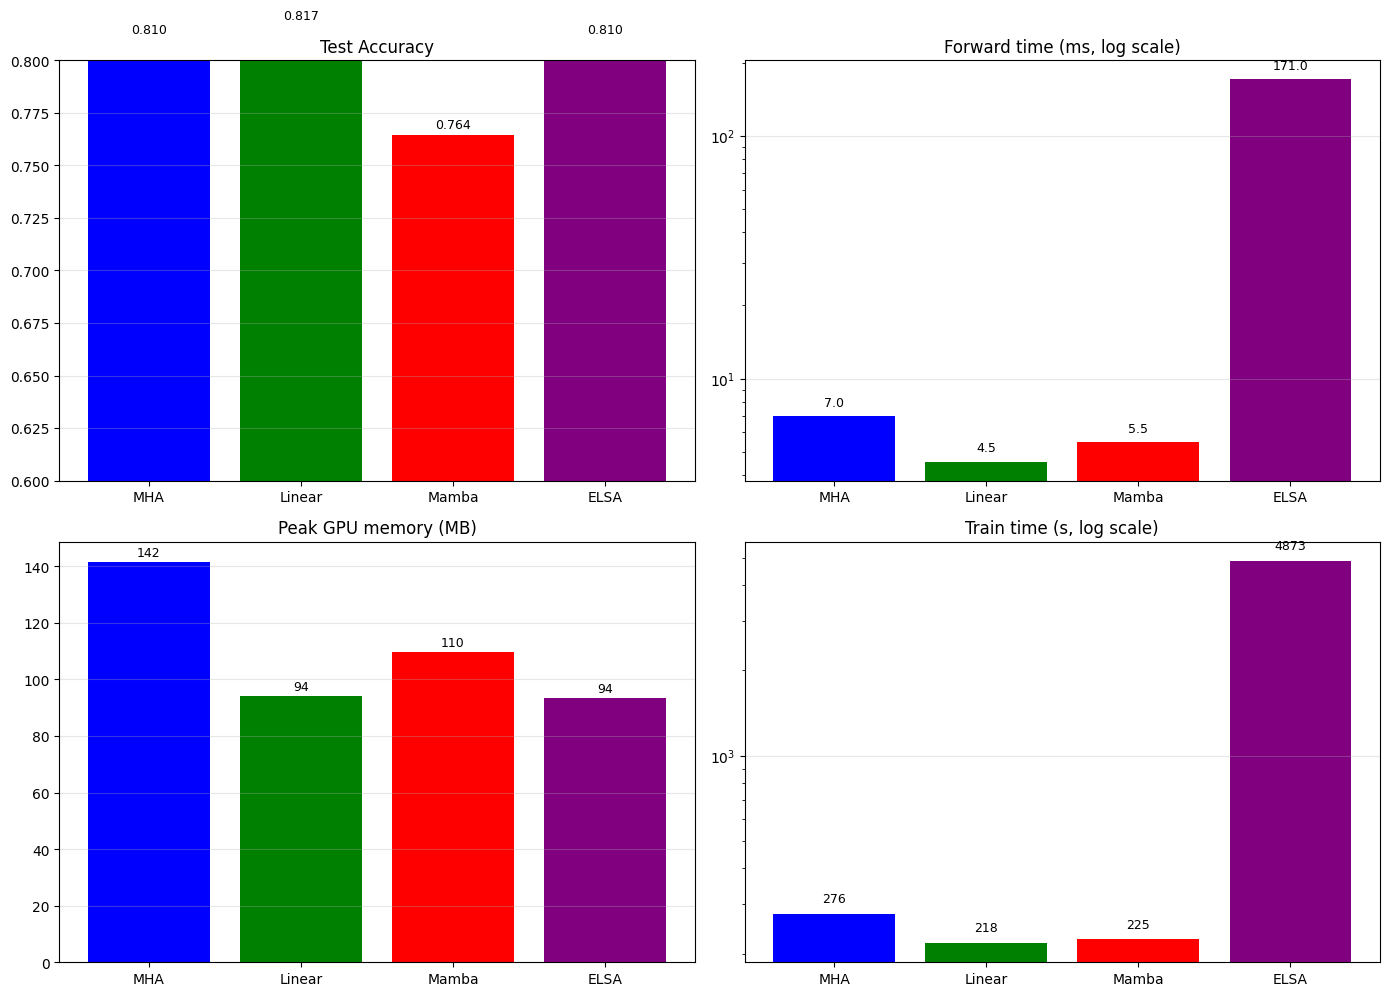

In [34]:
methods = df["Method"].tolist()
colors  = ["blue", "green", "red", "purple"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

axes[0].bar(methods, df["Test Acc"], color=colors)
axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0.6, 0.8)
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(df["Test Acc"]):
    axes[0].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(methods, df["Fwd time, ms"], color=colors)
axes[1].set_title("Forward time (ms, log scale)")
axes[1].set_yscale("log")
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(df["Fwd time, ms"]):
    axes[1].text(i, v * 1.1, f"{v:.1f}", ha="center", fontsize=9)

axes[2].bar(methods, df["Peak mem, MB"], color=colors)
axes[2].set_title("Peak GPU memory (MB)")
axes[2].grid(axis="y", alpha=0.3)
for i, v in enumerate(df["Peak mem, MB"]):
    axes[2].text(i, v + 2, f"{v:.0f}", ha="center", fontsize=9)

axes[3].bar(methods, df["Train time, s"], color=colors)
axes[3].set_title("Train time (s, log scale)")
axes[3].set_yscale("log")
axes[3].grid(axis="y", alpha=0.3)
for i, v in enumerate(df["Train time, s"]):
    axes[3].text(i, v * 1.1, f"{v:.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


Визуализация - как ведут себя все четыре метода при увеличении длины последовательности — от 64 до 1024 токенов

Левый график — время прямого прохода в миллисекундах.

Правый график — пиковое потребление памяти на GPU в мегабайтах.

T = 64
  MHA      time=   0.82 ms   mem=  17.9 MB
  Linear   time=   1.08 ms   mem=  17.9 MB
  Mamba    time=   1.01 ms   mem=  18.7 MB
  ELSA     time=  28.28 ms   mem=  17.7 MB
T = 128
  MHA      time=   0.43 ms   mem=  20.1 MB
  Linear   time=   0.64 ms   mem=  19.2 MB
  Mamba    time=   0.58 ms   mem=  20.4 MB
  ELSA     time=  39.26 ms   mem=  18.7 MB
T = 256
  MHA      time=   0.45 ms   mem=  27.6 MB
  Linear   time=   0.67 ms   mem=  21.7 MB
  Mamba    time=   0.58 ms   mem=  23.7 MB
  ELSA     time=  73.04 ms   mem=  20.7 MB
T = 512
  MHA      time=   1.13 ms   mem=  55.5 MB
  Linear   time=   0.66 ms   mem=  27.6 MB
  Mamba    time=   0.83 ms   mem=  30.5 MB
T = 1024
  MHA      time=   3.86 ms   mem= 156.7 MB
  Linear   time=   0.80 ms   mem=  36.8 MB
  Mamba    time=   1.15 ms   mem=  44.1 MB


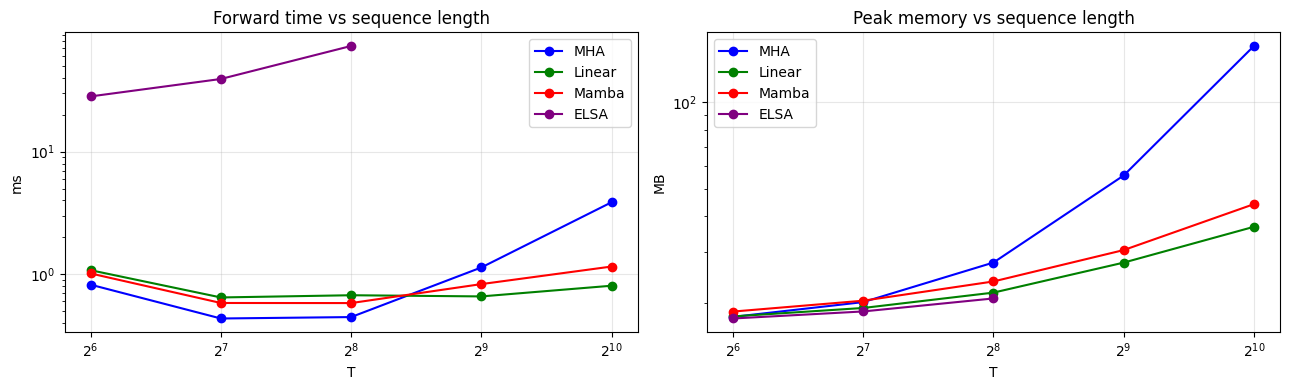

In [35]:
@torch.no_grad()
def bench_at_length(module_factory, T, B=4, d_model=128, n_warmup=2, n_iter=5):
    device = CFG.device
    mod = module_factory().to(device).eval()
    x = torch.randn(B, T, d_model, device=device)
    mask = torch.ones(B, T, device=device, dtype=torch.long)
    for _ in range(n_warmup):
        _ = mod(x, mask)
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats(device)
    s = torch.cuda.Event(enable_timing=True); e = torch.cuda.Event(enable_timing=True)
    times = []
    for _ in range(n_iter):
        s.record(); _ = mod(x, mask); e.record(); torch.cuda.synchronize()
        times.append(s.elapsed_time(e))
    mem = torch.cuda.max_memory_allocated(device) / 1024**2
    del mod; torch.cuda.empty_cache()
    return float(np.mean(times)), float(mem)

seq_lengths = [64, 128, 256, 512, 1024]
elsa_max_T  = 256

rows = []
for T in seq_lengths:
    print(f"T = {T}")
    for name, factory in ATTENTION.items():
        if name == "ELSA" and T > elsa_max_T:
            rows.append({"Method": name, "T": T, "time_ms": np.nan, "mem_MB": np.nan})
            continue
        try:
            t, m = bench_at_length(factory, T)
            rows.append({"Method": name, "T": T, "time_ms": t, "mem_MB": m})
            print(f"  {name:<8} time={t:7.2f} ms   mem={m:6.1f} MB")
        except RuntimeError as ex:
            print(f"  {name:<8} OOM/err at T={T}: {ex}")
            rows.append({"Method": name, "T": T, "time_ms": np.nan, "mem_MB": np.nan})

scale_df = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, col in zip(methods, colors):
    sub = scale_df[scale_df["Method"] == name]
    ax[0].plot(sub["T"], sub["time_ms"], "o-", label=name, color=col)
    ax[1].plot(sub["T"], sub["mem_MB"],  "o-", label=name, color=col)
ax[0].set_title("Forward time vs sequence length"); ax[0].set_xlabel("T"); ax[0].set_ylabel("ms")
ax[0].set_xscale("log", base=2); ax[0].set_yscale("log"); ax[0].grid(alpha=0.3); ax[0].legend()
ax[1].set_title("Peak memory vs sequence length");  ax[1].set_xlabel("T"); ax[1].set_ylabel("MB")
ax[1].set_xscale("log", base=2); ax[1].set_yscale("log"); ax[1].grid(alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()

 Левый: mha квадратичный, поэтому если последовательность увеличивается в 2 раза, то время x4. Linear Attention и Mamba растут значительно медленнее, ELSA показывается только до T=256, потому что на больших длинах работает слишком долго.

 Правый: в принципе идентично - у квадратичных методов память растёт резко, у линейных — плавно. поэтому по гпу на длинных последовательностях модель может просто не поместиться в память и упадет с Out Of Memory.

ИТОГИ:

ELSA показал полную совместимость с MHA: при одинаковой точности (0.8100) он требует меньше памяти (94 МБ против 141 МБ).

Linear-attention оказался лучшим вариантом на этой задаче — он дал максимальную точность при минимальном времени работы и низком потреблении памяти, хотя это во многом связано с особенностями датасета IMDB; на более сложных задачах MHA должна показывать себя лучше.

Mamba в данной постановке показала худшие результаты: хуже качество и более выраженное переобучение, поэтому её сильная сторона — не короткие классификационные задачи, а длинные последовательности и генеративные сценарии.

Все протестированные подходы склонны к переобучению уже на 8K примеров за 6–8 эпох, нужны early stopping и регуляризация (dropout, weight decay, аугментации данных).

Также видно, что 25 эпох избыточны: оптимум достигается примерно на 5–7 эпохах, а дальнейшее обучение не улучшает точность и лишь ухудшает поведение loss.